In [12]:
!pip install -q sentence-transformers

In [13]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [14]:
sentences = [
    # Cricket (4)
    "The bowler took three wickets in a single over.",
    "The bowler delivered a fast yorker to dismiss the batsman.",
    "The batsman scored a century in the final match.",
    "The team won the cricket match by chasing a big target.",

    # Cooking (3)
    "The chef prepared a delicious pasta with fresh ingredients.",
    "Baking a cake requires precise measurements and timing.",
    "Spices enhance the flavor of traditional Indian dishes.",

    # Cybersecurity (3)
    "Strong passwords are essential to protect online accounts.",
    "Phishing attacks trick users into revealing sensitive information.",
    "Firewalls help prevent unauthorized access to networks."
]

In [15]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


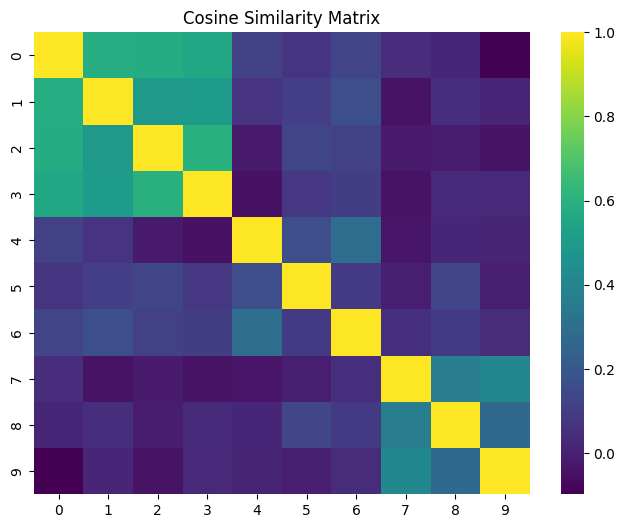

In [16]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=False, cmap='viridis')
plt.title("Cosine Similarity Matrix")
plt.show()

In [17]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Sentence: The bowler took three wickets in a single over.
Similarity Score: 0.9669

Sentence: The bowler delivered a fast yorker to dismiss the batsman.
Similarity Score: 0.5721

